# 02 — Select best k and generate plots

Inputs:
- result_sim_{reg}_{k}.csv (from Notebook 01)
- data_sim_{reg}_true.csv (exported truth table for simulation)
- centroid tables: data_sgp_subzones.csv, data_seoul_subzones.csv (optional but used for maps)


# Path

In [2]:
from pathlib import Path
import os
import random
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Reproducibility (for sampling)
SEED = int(os.getenv("PROJECT_SEED", "42"))
random.seed(SEED)
np.random.seed(SEED)

# Optional: Colab Drive mount (only needed if you run in Colab)
IN_COLAB = "COLAB_GPU" in os.environ
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

DEFAULT_SIM_PATH_DATA = "/content/drive/MyDrive/Colab Notebooks/Workspace/od_matrix_generation/od-recovery-r1/od_sim_data/"
path_od_sim_data = Path(os.getenv("OD_SIM_PATH_DATA", DEFAULT_SIM_PATH_DATA))

DEFAULT_SIM_PATH_RESULT = "/content/drive/MyDrive/Colab Notebooks/Workspace/od_matrix_generation/od-recovery-r1/od_sim_result/"
path_od_sim_result = Path(os.getenv("OD_SIM_PATH_RESULT", DEFAULT_SIM_PATH_RESULT))

print("SEED =", SEED)
print("path_od_sim_data =", path_od_sim_data)
print("path_od_sim_result =", path_od_sim_result)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SEED = 42
path_od_sim_data = /content/drive/MyDrive/Colab Notebooks/Workspace/od_matrix_generation/od-recovery-r1/od_sim_data
path_od_sim_result = /content/drive/MyDrive/Colab Notebooks/Workspace/od_matrix_generation/od-recovery-r1/od_sim_result


# Select best k (robust error + optional R²)

In [3]:
from typing import Iterable, Union, Optional

def select_best_k_from_csvs_robust_error_with_r2(
    path_od_result: Union[str, Path],
    reg: str,
    k_values: Optional[Iterable[float]] = None,
    pred_col_for_robust: str = "COUNT",
    pred_col_for_r2: str = "COUNT",
    true_df: Optional[pd.DataFrame] = None,
    true_count_col: str = "COUNT",
    min_count: float = 1,
    center: str = "median",
    round_counts_for_r2: bool = True,
) -> tuple[float, pd.DataFrame]:
    """
    Select k by OD-level robust error across candidate runs.
    Optionally compute R² against simulation truth.
    """
    OD_KEYS = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE"]

    if k_values is None:
        k_values = [round(0.2 * i, 1) for i in range(11)]
    else:
        k_values = list(k_values)

    p = Path(path_od_result)

    # Prepare true_df (OD-level)
    true_index = None
    true_vals_full = None
    if true_df is not None:
        tdf = true_df[OD_KEYS + [true_count_col]].copy()
        tdf[true_count_col] = pd.to_numeric(tdf[true_count_col], errors="coerce").fillna(0.0)
        tdf = tdf.groupby(OD_KEYS, as_index=False)[true_count_col].sum()
        if round_counts_for_r2:
            tdf[true_count_col] = np.round(tdf[true_count_col])
        tdf = tdf[tdf[true_count_col] >= float(min_count)]
        tdf = tdf.sort_values(OD_KEYS, kind="mergesort").reset_index(drop=True)

        true_index = pd.MultiIndex.from_frame(tdf[OD_KEYS], names=OD_KEYS)
        true_vals_full = tdf[true_count_col].to_numpy(dtype=float, copy=False)

    # Load candidates
    k_to_series = {}
    k_to_series_r2 = {}
    union_keys = None

    for k in k_values:
        fp = p / f"result_sim_{reg}_{k}.csv"
        df = pd.read_csv(fp)

        df[pred_col_for_robust] = pd.to_numeric(df[pred_col_for_robust], errors="coerce").fillna(0.0)
        df_rob = df.groupby(OD_KEYS, as_index=False)[pred_col_for_robust].sum()

        cur_keys = df_rob[OD_KEYS].drop_duplicates()
        union_keys = cur_keys if union_keys is None else (
            pd.concat([union_keys, cur_keys], ignore_index=True).drop_duplicates()
        )

        k_to_series[k] = df_rob.set_index(OD_KEYS)[pred_col_for_robust]

        if true_df is not None:
            df[pred_col_for_r2] = pd.to_numeric(df[pred_col_for_r2], errors="coerce").fillna(0.0)
            df_r2 = df.groupby(OD_KEYS, as_index=False)[pred_col_for_r2].sum()
            k_to_series_r2[k] = df_r2.set_index(OD_KEYS)[pred_col_for_r2]

    union_keys = union_keys.sort_values(OD_KEYS, kind="mergesort").reset_index(drop=True)
    union_index = pd.MultiIndex.from_frame(union_keys, names=OD_KEYS)

    # Assemble matrix X (K x N)
    K = len(k_values)
    N = len(union_index)
    X = np.empty((K, N), dtype=float)
    for i, k in enumerate(k_values):
        X[i, :] = (
            k_to_series[k].reindex(union_index, fill_value=0.0).to_numpy(dtype=float, copy=False)
        )

    # Center and robust error
    if center == "median":
        C = np.nanmedian(X, axis=0)
    elif center == "mean":
        C = np.nanmean(X, axis=0)
    else:
        raise ValueError("center must be 'median' or 'mean'")

    robust_error = np.sqrt(np.nanmean((X - C) ** 2, axis=1))

    # R2 (optional)
    r2_list = [np.nan] * len(k_values)
    if true_df is not None:
        for i, k in enumerate(k_values):
            pred = (
                k_to_series_r2[k].reindex(true_index, fill_value=0.0).to_numpy(dtype=float, copy=False)
            )
            if round_counts_for_r2:
                pred = np.round(pred)

            mask = (true_vals_full >= min_count) & (pred >= min_count)
            y_true = true_vals_full[mask]
            y_pred = pred[mask]

            if y_true.size > 1:
                y_bar = y_true.mean()
                sst = np.sum((y_true - y_bar) ** 2)
                if sst > 0:
                    sse = np.sum((y_true - y_pred) ** 2)
                    r2_list[i] = 1.0 - sse / sst

    metrics = (
        pd.DataFrame({"k": k_values, "ROBUST_ERROR": robust_error, "R2": r2_list})
        .sort_values("k", kind="mergesort")
        .reset_index(drop=True)
    )

    best_k = float(metrics.loc[metrics["ROBUST_ERROR"].idxmin(), "k"])
    return best_k, metrics


# Run k-selection

In [4]:
for reg in ["seoul"]:
    print("=================================")
    print('Region: ', reg)
    k_values = [round(0.2 * i, 1) for i in range(11)]

    true_counts = pd.read_csv(path_od_sim_data / f"data_sim_{reg}_true.csv")

    best_k, table = select_best_k_from_csvs_robust_error_with_r2(
        path_od_result=path_od_sim_result,
        reg=reg,
        k_values=k_values,
        pred_col_for_robust="COUNT",
        pred_col_for_r2="COUNT",
        true_df=true_counts,
        min_count=1,
        center="median",
    )

    print("Best k:", best_k)
    display(table)
    #table.to_csv(path_od_sim / f"selected_k_{reg}.csv", index=False)


Region:  seoul
Best k: 0.6


,k,ROBUST_ERROR,R2
0,0.0,2.795742,0.910915
1,0.2,2.129126,0.905883
2,0.4,1.707390,0.894326
3,0.6,1.344540,0.887433
4,0.8,1.404480,0.884143
5,1.0,1.548520,0.876533
6,1.2,1.768432,0.864765
7,1.4,2.001388,0.861701
8,1.6,2.045545,0.857570
9,1.8,2.234659,0.854026


# Plotting (scatter + centroid maps)

In [5]:
import math
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from matplotlib.colors import Normalize
from sklearn.metrics import r2_score

COLORS = {"intra": "#B03A2E", "inter": "#1F4E79"}
color_map = "viridis"
KEY_OD = ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE"]
MODE_NAME = {"WK_COUNT": "Walk", "VH_COUNT": "Private vehicle", "COUNT": "All modes"}
REGION_NAME = {"seoul": "Seoul"}

def aggregate_counts(df: pd.DataFrame, key_cols: list[str], count_col: str = "COUNT") -> pd.DataFrame:
    out = df[key_cols + [count_col]].copy()
    out[count_col] = out.groupby(key_cols)[count_col].transform("sum")
    out = out.drop_duplicates().rename(columns={count_col: "COUNT"})
    return out

def round_and_threshold(df: pd.DataFrame, min_count: float = 1.0) -> pd.DataFrame:
    out = df.copy()
    out["COUNT"] = np.round(out["COUNT"])
    return out[out["COUNT"] >= min_count].copy()

def plot_od_scatter_ax(ax, pred_df, true_df, *, colors, max_val, x_label, y_label):
    pred = aggregate_counts(pred_df, KEY_OD)
    true = aggregate_counts(true_df, KEY_OD)

    df = pred.merge(true, on=KEY_OD, suffixes=("_pred", "_true"))
    if len(df) == 0:
        ax.text(0.5, 0.5, "No matched OD pairs", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return

    y_pred = df["COUNT_pred"].to_numpy(float)
    y_true = df["COUNT_true"].to_numpy(float)
    is_intra = (df["ORIGIN_SUBZONE"].astype(str) == df["DESTINATION_SUBZONE"].astype(str)).to_numpy(bool)

    denom = y_pred.sum() + y_true.sum()
    cpc = 2 * np.minimum(y_pred, y_true).sum() / denom if denom > 0 else np.nan
    r2 = r2_score(y_true, y_pred) if len(df) > 1 else np.nan

    ax.scatter(y_true[~is_intra], y_pred[~is_intra], s=3, alpha=0.25, color=colors["inter"], label="Inter-zone")
    ax.scatter(y_true[is_intra], y_pred[is_intra], s=5, alpha=0.45, color=colors["intra"], label="Intra-zone")

    vmax = max_val if max_val is not None else max(float(y_true.max()), float(y_pred.max()))
    vmax = max(vmax, 1.0)
    ax.plot([1, vmax], [1, vmax], "--", color="black", linewidth=0.8)

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.xaxis.set_major_formatter(mticker.LogFormatterMathtext())
    ax.yaxis.set_major_formatter(mticker.LogFormatterMathtext())
    ax.set_xlabel(x_label); ax.set_ylabel(y_label)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(frameon=False, fontsize=10, loc="lower right", markerscale=3.0, handletextpad=0.4)
    ax.text(0.05, 0.95, f"CPC = {cpc:.2f}\n$R^2$ = {r2:.2f}", transform=ax.transAxes,
            ha="left", va="top", fontsize=10)

def get_centroids_for_region(reg: str, data_seoul_subzone: pd.DataFrame) -> pd.DataFrame:
    if reg == "seoul":
        centroids = data_seoul_subzone
    else:
        raise ValueError(f"Unknown region: {reg}")
    out = centroids[["SUBZONE_C", "X", "Y"]].drop_duplicates().copy()
    out["SUBZONE_C"] = out["SUBZONE_C"].astype(str)
    out["X"] = out["X"].astype(float)
    out["Y"] = out["Y"].astype(float)
    return out

def prepare_inter_xy(df: pd.DataFrame, centroids: pd.DataFrame) -> pd.DataFrame:
    od = df.copy()
    c = centroids.copy()

    od["ORIGIN_SUBZONE"] = od["ORIGIN_SUBZONE"].astype(str)
    od["DESTINATION_SUBZONE"] = od["DESTINATION_SUBZONE"].astype(str)
    c["SUBZONE_C"] = c["SUBZONE_C"].astype(str)

    od = od.merge(c, left_on="ORIGIN_SUBZONE", right_on="SUBZONE_C", how="left") \
           .rename(columns={"X": "OX", "Y": "OY"}) \
           .drop(columns="SUBZONE_C")

    od = od.merge(c, left_on="DESTINATION_SUBZONE", right_on="SUBZONE_C", how="left") \
           .rename(columns={"X": "DX", "Y": "DY"}) \
           .drop(columns="SUBZONE_C")

    od = od.dropna(subset=["OX", "OY", "DX", "DY"]).copy()

    od["COUNT"] = od.groupby(["ORIGIN_SUBZONE", "DESTINATION_SUBZONE", "OX", "OY", "DX", "DY"])["COUNT"].transform("sum")
    return od.drop_duplicates()



def plot_maps_row(
    fig,
    axes,
    *,
    reg: str,
    pred_od: pd.DataFrame,
    true_od: pd.DataFrame,
    data_subzone: pd.DataFrame,
    min_count: float = 1.0,
    base_point_size: float = 3.0,
    intra_point_size: float = 14.0,
):
    centroids = get_centroids_for_region(
        reg,
        data_seoul_subzone=data_seoul_subzone,
    )

    pred = pred_od.copy()
    true = true_od.copy()

    for col in ["ORIGIN_SUBZONE", "DESTINATION_SUBZONE"]:
        pred[col] = pred[col].astype(str)
        true[col] = true[col].astype(str)

    pred = pred[pred["COUNT"] >= min_count].copy()
    true = true[true["COUNT"] >= min_count].copy()

    pred_xy = prepare_inter_xy(pred, centroids)
    true_xy = prepare_inter_xy(true, centroids)

    # Separate scales (no log)
    intra_vals = pd.concat([
        pred.loc[pred.ORIGIN_SUBZONE == pred.DESTINATION_SUBZONE, "COUNT"],
        true.loc[true.ORIGIN_SUBZONE == true.DESTINATION_SUBZONE, "COUNT"],
    ], ignore_index=True)
    vmax_intra = int(math.ceil(max(intra_vals.quantile(0.995) if len(intra_vals) else 0.0, 1.0)))

    inter_vals = pd.concat([
        pred_xy.loc[pred_xy.ORIGIN_SUBZONE != pred_xy.DESTINATION_SUBZONE, "COUNT"],
        true_xy.loc[true_xy.ORIGIN_SUBZONE != true_xy.DESTINATION_SUBZONE, "COUNT"],
    ], ignore_index=True)
    vmax_inter = int(math.ceil(max(inter_vals.quantile(0.995) if len(inter_vals) else 0.0, 1.0)))

    cmap = cm.get_cmap(color_map)
    norm_intra = Normalize(vmin=0.0, vmax=vmax_intra)
    norm_inter = Normalize(vmin=0.0, vmax=vmax_inter)

    # Frame / extent based on centroids
    xmin, xmax = float(centroids["X"].min()), float(centroids["X"].max())
    ymin, ymax = float(centroids["Y"].min()), float(centroids["Y"].max())
    xpad = 0.03 * (xmax - xmin) if xmax > xmin else 1.0
    ypad = 0.03 * (ymax - ymin) if ymax > ymin else 1.0

    def _setup_ax(ax):
        ax.set_axis_off()
        ax.set_xlim(xmin - xpad, xmax + xpad)
        ax.set_ylim(ymin - ypad, ymax + ypad)

        # faint background dots = all subzones
        ax.scatter(
            centroids["X"], centroids["Y"],
            s=base_point_size,
            alpha=0.25,
            linewidths=0.0,
            color="black",
            zorder=1,
        )

    # Intra-zone: centroid circles with color = intra flow
    for ax, df in zip(axes[:2], [pred, true]):
        _setup_ax(ax)

        intra_zone_sum = (
            df.loc[df.ORIGIN_SUBZONE == df.DESTINATION_SUBZONE]
              .groupby("DESTINATION_SUBZONE")["COUNT"].sum()
        )

        g = centroids.copy()
        g["COUNT"] = g["SUBZONE_C"].map(intra_zone_sum).fillna(0.0).astype(float)

        ax.scatter(
            g["X"], g["Y"],
            c=g["COUNT"].to_numpy(float),
            cmap=cmap,
            norm=norm_intra,
            s=intra_point_size,
            alpha=0.95,
            linewidths=0.0,
            zorder=3,
        )

    # Inter-zone: lines
    for ax, df in zip(axes[2:], [pred_xy, true_xy]):
        _setup_ax(ax)

        inter_df = (
            df[df.ORIGIN_SUBZONE != df.DESTINATION_SUBZONE]
            .sort_values("COUNT", ascending=True)
        )

        for _, r in inter_df.iterrows():
            ax.plot(
                [r.OX, r.DX],
                [r.OY, r.DY],
                color=cmap(norm_inter(float(r.COUNT))),
                linewidth=0.6,
                alpha=0.75,
                zorder=2,
            )

    # Panel labels
    panel_labels = ["Recovered", "True", "Recovered", "True"]
    for ax, lab in zip(axes, panel_labels):
        ax.text(
            0.02, 0.98, lab,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor="white",
                edgecolor="none",
                alpha=0.85,
            ),
            zorder=10,
        )

    # Two colorbars (same cmap, different scales)
    cbar_intra = fig.colorbar(
        cm.ScalarMappable(norm=norm_intra, cmap=cmap),
        ax=axes[:2],
        orientation="horizontal",
        pad=0.2,
        fraction=0.015,
    )
    cbar_inter = fig.colorbar(
        cm.ScalarMappable(norm=norm_inter, cmap=cmap),
        ax=axes[2:],
        orientation="horizontal",
        pad=0.2,
        fraction=0.015,
    )

    cbar_intra.set_ticks([0.0, float(vmax_intra)])
    cbar_inter.set_ticks([0.0, float(vmax_inter)])

# Execute plots for both regions and modes

[OK] Centroid tables loaded.

Region: Seoul (k=0.6)
  - Mode: Walk


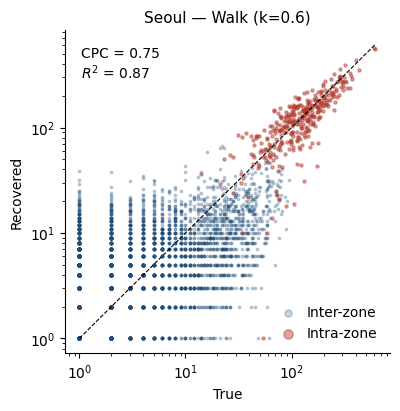

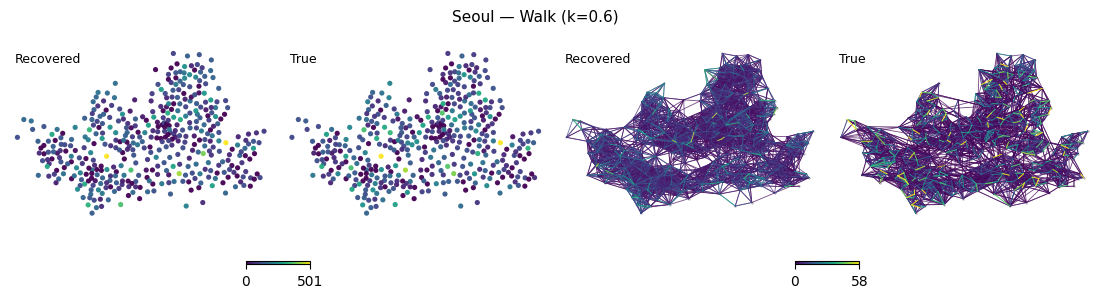

  - Mode: Private vehicle


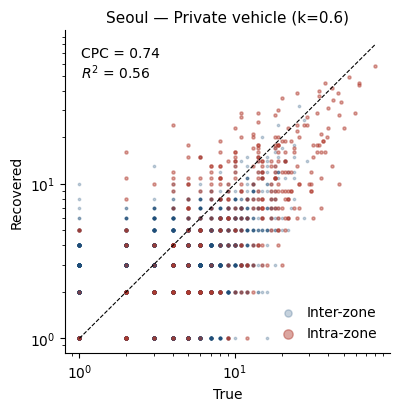

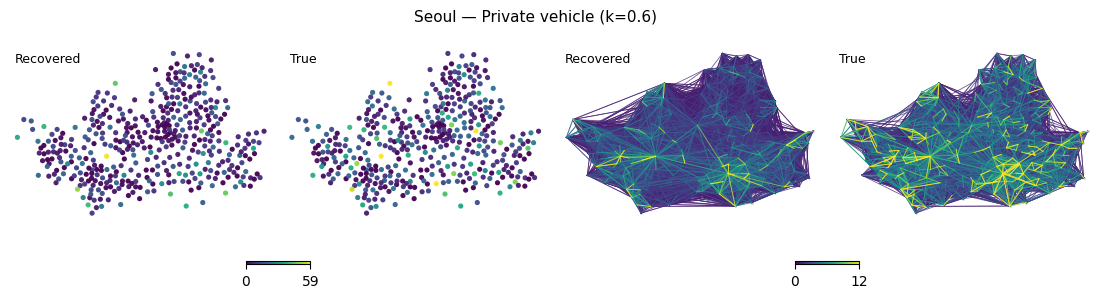

  - Mode: All modes


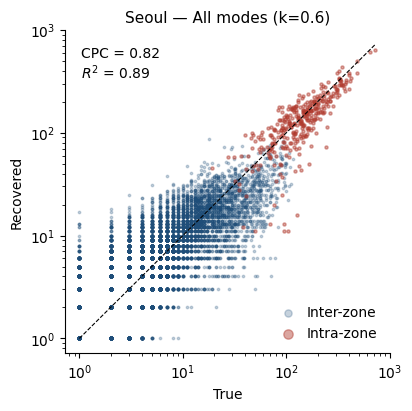

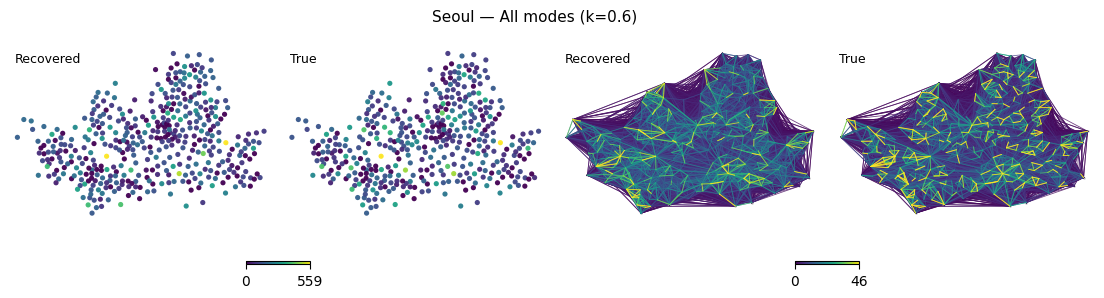


Done. All figures displayed.


In [6]:
# ======================================================
# Call functions: execute plots for both regions and modes
#   (display only — no file saving)
# ======================================================
# Assumes all helper functions and constants are already defined:
# - aggregate_counts, round_and_threshold
# - plot_od_scatter_ax, plot_maps_row
# - KEY_OD, MODE_NAME, REGION_NAME, COLORS
# - path_od_sim
# ======================================================

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Settings
# -----------------------
regions_to_plot = ["seoul"]
modes_to_plot = ["WK_COUNT", "VH_COUNT", "COUNT"]
min_count = 1.0

# -----------------------
# Load centroid tables (optional; required for maps)
# -----------------------
centroid_seoul_fp = Path(path_od_sim_data) / "data_seoul_subzones.csv"

centroids_available = centroid_seoul_fp.exists()
if centroids_available:
    data_seoul_subzone = pd.read_csv(centroid_seoul_fp)
    print("[OK] Centroid tables loaded.")
else:
    print("[WARN] Centroid tables not found. Maps will be skipped.")

# -----------------------
# Loop: regions × modes
# -----------------------
for reg in regions_to_plot:
    region_title = REGION_NAME.get(reg, reg)

    if reg == 'seoul':
        k = 0.6          # set to best_k if desired

    pred_fp = Path(path_od_sim_result) / f"result_sim_{reg}_{k}.csv"
    true_fp = Path(path_od_sim_data) / f"data_sim_{reg}_true.csv"

    print("\n===========================================")
    print("Region:", region_title, f"(k={k})")

    if not pred_fp.exists():
        print(f"[SKIP] Missing predicted file: {pred_fp.name}")
        continue
    if not true_fp.exists():
        print(f"[SKIP] Missing true file: {true_fp.name}")
        continue

    pred_raw = pd.read_csv(pred_fp)
    true_raw = pd.read_csv(true_fp)

    # Ensure consistent OD key dtypes
    for c in KEY_OD:
        if c in pred_raw.columns:
            pred_raw[c] = pred_raw[c].astype(str)
        if c in true_raw.columns:
            true_raw[c] = true_raw[c].astype(str)

    for mode in modes_to_plot:
        mode_title = MODE_NAME.get(mode, mode)
        print("  - Mode:", mode_title)

        if mode not in pred_raw.columns:
            print(f"    [SKIP] pred missing column: {mode}")
            continue
        if mode not in true_raw.columns:
            print(f"    [SKIP] true missing column: {mode}")
            continue

        # ----------------------------------------
        # Prepare OD tables
        # ----------------------------------------
        pred_od = aggregate_counts(
            pred_raw[KEY_OD + [mode]].rename(columns={mode: "COUNT"}),
            KEY_OD
        )
        true_od = aggregate_counts(
            true_raw[KEY_OD + [mode]].rename(columns={mode: "COUNT"}),
            KEY_OD
        )

        pred_od = round_and_threshold(pred_od, min_count=min_count)
        true_od = round_and_threshold(true_od, min_count=min_count)

        if pred_od.empty or true_od.empty:
            print("    [SKIP] Empty OD table after thresholding.")
            continue

        max_scatter = max(
            float(pred_od["COUNT"].max()),
            float(true_od["COUNT"].max()),
            1.0
        )

        # ----------------------------------------
        # FIG 1 — OD scatter (display only)
        # ----------------------------------------
        fig1, ax = plt.subplots(figsize=(4.2, 4.2))
        plot_od_scatter_ax(
            ax,
            pred_df=pred_od,
            true_df=true_od,
            colors=COLORS,
            max_val=max_scatter,
            x_label="True",
            y_label="Recovered",
        )
        ax.set_title(f"{region_title} — {mode_title} (k={k})", fontsize=11)
        plt.show()
        plt.close(fig1)

        # ----------------------------------------
        # FIG 2 — Centroid-only maps (display only)
        # ----------------------------------------
        if not centroids_available:
            continue

        fig2 = plt.figure(figsize=(14, 2.8))
        gs = fig2.add_gridspec(1, 4, wspace=0.05)
        axes = [fig2.add_subplot(gs[0, i]) for i in range(4)]

        plot_maps_row(
            fig2,
            axes,
            reg=reg,
            pred_od=pred_od,
            true_od=true_od,
            data_subzone=data_seoul_subzone,
            min_count=min_count,
        )
        fig2.suptitle(f"{region_title} — {mode_title} (k={k})", y=1.02, fontsize=11)
        plt.show()
        plt.close(fig2)

print("\nDone. All figures displayed.")
